# Stage 0 — Combine & Preprocess All Q-CHAT-10 Datasets

This notebook:
1. Loads all compatible Q-CHAT-10 datasets from the raw data directory
2. Normalises each to a common raw schema
3. Concatenates them into one unified dataset
4. Removes duplicate rows
5. Preprocesses to match the format expected by QM1.ipynb
6. Saves the final combined preprocessed dataset

**Sources used:**
- `Autism Dataset for Toddlers.csv` — toddlers (Age in months)
- `Children_ASD.csv` — children (Age in years)
- `Autism-Child-Data.arff` — children (Age in years)
- `Autism-Adolescent-Data.arff` — adolescents (Age in years)
- `Autism_Screening_Data_Combined.csv` — mixed ages (Age in years)

**Excluded:**
- `Toddler Autism dataset July 2018.csv` — identical duplicate of Toddlers CSV
- `data1.csv` — incompatible format (25-item QCHAT, different schema)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.preprocessing import StandardScaler

DATA_DIR = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\Q_CHAT_10"
OUTPUT_PATH = r"C:\Users\Yasindu\Desktop\Stuff\Research\Datasets\PrePROCESSED DATA\pre_processed_data_combined.csv"

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load & Normalise Each Dataset

All datasets are normalised to the following raw schema before combining:

| Column | Type | Notes |
|---|---|---|
| A1–A10 | int (0/1) | Q-CHAT-10 binary responses |
| Age_in_Months | int | Converted from years × 12 where needed |
| Sex | str | 'M' or 'F' |
| Jaundice | str | 'Yes' or 'No' |
| Family_mem_with_ASD | str | 'Yes' or 'No' |
| Who_completed_the_test | str | 'Family Member' / 'Health Care Professional' / 'Others' / 'School and NGO' |
| ASD_traits | str | 'Yes' or 'No' (target) |
| source | str | Dataset origin tag |

### 1.1 Toddlers Dataset (`Autism Dataset for Toddlers.csv`)

In [10]:
df_toddlers = pd.read_csv(f"{DATA_DIR}\\Autism Dataset for Toddlers.csv")
print(f"Raw shape: {df_toddlers.shape}")
df_toddlers.head(3)

Raw shape: (1054, 19)


,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes


In [11]:
def normalise_who(val):
    """Standardise the 'Who completed the test' values across all datasets."""
    val = str(val).strip().lower()
    if val in ['family member', 'parent', 'relative']:
        return 'Family Member'
    elif val in ['health care professional', 'health care professional']:
        return 'Health Care Professional'
    elif val in ['school and ngo']:
        return 'School and NGO'
    else:  # self, others, ?, unknown, nan
        return 'Others'

def normalise_yesno(val, true_vals):
    """Normalise a yes/no column."""
    return 'Yes' if str(val).strip().lower() in true_vals else 'No'

def normalise_sex(val):
    return 'M' if str(val).strip().lower() == 'm' else 'F'

def normalise_asd(val):
    return 'Yes' if str(val).strip().lower() in ['yes', 'y'] else 'No'

print("Helper functions defined.")

Helper functions defined.


In [12]:
toddlers_norm = pd.DataFrame()
for col in ['A1','A2','A3','A4','A5','A6','A7','A8','A9']:
    toddlers_norm[col] = df_toddlers[col].astype(int)
toddlers_norm['A10'] = df_toddlers['A10'].astype(int)

# Age already in months
toddlers_norm['Age_in_Months'] = df_toddlers['Age_Mons'].astype(int)

toddlers_norm['Sex']                 = df_toddlers['Sex'].apply(normalise_sex)
toddlers_norm['Jaundice']            = df_toddlers['Jaundice'].apply(lambda x: normalise_yesno(x, ['yes','y']))
toddlers_norm['Family_mem_with_ASD'] = df_toddlers['Family_mem_with_ASD'].apply(lambda x: normalise_yesno(x, ['yes','y']))
toddlers_norm['Who_completed_the_test'] = df_toddlers['Who completed the test'].apply(normalise_who)
toddlers_norm['ASD_traits']          = df_toddlers['Class/ASD Traits '].apply(normalise_asd)
toddlers_norm['source']              = 'toddlers_csv'

print(f"Toddlers normalised shape: {toddlers_norm.shape}")
toddlers_norm.head(3)

Toddlers normalised shape: (1054, 17)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_in_Months,Sex,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits,source
0,0,0,0,0,0,0,1,1,0,1,28,F,Yes,No,Family Member,No,toddlers_csv
1,1,1,0,0,0,1,1,0,0,0,36,M,Yes,No,Family Member,Yes,toddlers_csv
2,1,0,0,0,0,0,1,1,0,1,36,M,Yes,No,Family Member,Yes,toddlers_csv


### 1.2 Children Dataset (`Children_ASD.csv`)

In [13]:
df_children = pd.read_csv(f"{DATA_DIR}\\Children_ASD.csv")
print(f"Raw shape: {df_children.shape}")
df_children.head(3)

Raw shape: (2226, 18)


,Unnamed: 0,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Years,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,0,0,0,0,0,0,0,1,1,0,1,2,F,Middle Eastern,Yes,No,Family Member,No
1,1,1,1,0,0,0,1,1,0,0,0,3,M,White European,Yes,No,Family Member,Yes
2,2,1,0,0,0,0,0,1,1,0,1,3,M,Middle Eastern,Yes,No,Family Member,Yes


In [14]:
children_norm = pd.DataFrame()
for col in ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10']:
    children_norm[col] = df_children[col].astype(int)

# Age in years → months
children_norm['Age_in_Months'] = (df_children['Age_Years'] * 12).astype(int)

children_norm['Sex']                 = df_children['Sex'].apply(normalise_sex)
children_norm['Jaundice']            = df_children['Jaundice'].apply(lambda x: normalise_yesno(x, ['yes','y']))
children_norm['Family_mem_with_ASD'] = df_children['Family_mem_with_ASD'].apply(lambda x: normalise_yesno(x, ['yes','y']))
children_norm['Who_completed_the_test'] = df_children['Who_completed_the_test'].apply(normalise_who)
children_norm['ASD_traits']          = df_children['ASD_traits'].apply(normalise_asd)
children_norm['source']              = 'children_csv'

print(f"Children normalised shape: {children_norm.shape}")
children_norm.head(3)

Children normalised shape: (2226, 17)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_in_Months,Sex,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits,source
0,0,0,0,0,0,0,1,1,0,1,24,F,Yes,No,Family Member,No,children_csv
1,1,1,0,0,0,1,1,0,0,0,36,M,Yes,No,Family Member,Yes,children_csv
2,1,0,0,0,0,0,1,1,0,1,36,M,Yes,No,Family Member,Yes,children_csv


### 1.3 Child ARFF Dataset (`Autism-Child-Data.arff`)

In [15]:
raw_child_arff, _ = arff.loadarff(f"{DATA_DIR}\\Autism-Child-Data.arff")
df_child_arff = pd.DataFrame(raw_child_arff)

# Decode bytes columns
for col in df_child_arff.select_dtypes(object).columns:
    df_child_arff[col] = df_child_arff[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

print(f"Raw shape: {df_child_arff.shape}")
df_child_arff.head(3)

Raw shape: (292, 21)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5.0,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,Middle Eastern,no,no,Jordan,no,5.0,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,?,no,no,Jordan,yes,5.0,4-11 years,?,NO


In [17]:
child_arff_norm = pd.DataFrame()
for i, col in enumerate(['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
                          'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score'], start=1):
    child_arff_norm[f'A{i}'] = df_child_arff[col].astype(int)

# Age in years → months (drop rows where age is NaN)
age_nan_count = df_child_arff['age'].isna().sum()
if age_nan_count > 0:
    print(f"  Dropping {age_nan_count} rows with missing age")
    valid_mask = df_child_arff['age'].notna()
    df_child_arff = df_child_arff[valid_mask].reset_index(drop=True)
    child_arff_norm = child_arff_norm[valid_mask.values].reset_index(drop=True)

child_arff_norm['Age_in_Months'] = (df_child_arff['age'] * 12).astype(int)

child_arff_norm['Sex']                 = df_child_arff['gender'].apply(normalise_sex)
child_arff_norm['Jaundice']            = df_child_arff['jundice'].apply(lambda x: normalise_yesno(x, ['yes','y']))
child_arff_norm['Family_mem_with_ASD'] = df_child_arff['austim'].apply(lambda x: normalise_yesno(x, ['yes','y']))
child_arff_norm['Who_completed_the_test'] = df_child_arff['relation'].apply(normalise_who)
child_arff_norm['ASD_traits']          = df_child_arff['Class/ASD'].apply(normalise_asd)
child_arff_norm['source']              = 'child_arff'

print(f"Child ARFF normalised shape: {child_arff_norm.shape}")
child_arff_norm.head(3)

  Dropping 4 rows with missing age
Child ARFF normalised shape: (288, 17)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_in_Months,Sex,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits,source
0,1,1,0,0,1,1,0,1,0,0,72,M,No,No,Family Member,No,child_arff
1,1,1,0,0,1,1,0,1,0,0,72,M,No,No,Family Member,No,child_arff
2,1,1,0,0,0,1,1,1,0,0,72,M,No,No,Others,No,child_arff


### 1.4 Adolescent ARFF Dataset (`Autism-Adolescent-Data.arff`)

In [18]:
raw_adol_arff, _ = arff.loadarff(f"{DATA_DIR}\\Autism-Adolescent-Data.arff")
df_adol_arff = pd.DataFrame(raw_adol_arff)

# Decode bytes columns
for col in df_adol_arff.select_dtypes(object).columns:
    df_adol_arff[col] = df_adol_arff[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

print(f"Raw shape: {df_adol_arff.shape}")
df_adol_arff.head(3)

Raw shape: (104, 21)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,0,0,0,1,1,1,1,1,1,0,...,m,Hispanic,yes,yes,Austria,no,6.0,12-16 years,Parent,NO
1,0,0,0,0,0,0,0,0,1,1,...,m,Black,no,no,Austria,no,2.0,12-16 years,Relative,NO
2,0,0,0,0,0,0,0,0,1,1,...,f,?,no,no,AmericanSamoa,no,2.0,12-16 years,?,NO


In [19]:
adol_arff_norm = pd.DataFrame()
for i, col in enumerate(['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
                          'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score'], start=1):
    adol_arff_norm[f'A{i}'] = df_adol_arff[col].astype(int)

# Age in years → months
adol_arff_norm['Age_in_Months'] = (df_adol_arff['age'] * 12).astype(int)

adol_arff_norm['Sex']                 = df_adol_arff['gender'].apply(normalise_sex)
adol_arff_norm['Jaundice']            = df_adol_arff['jundice'].apply(lambda x: normalise_yesno(x, ['yes','y']))
adol_arff_norm['Family_mem_with_ASD'] = df_adol_arff['austim'].apply(lambda x: normalise_yesno(x, ['yes','y']))
adol_arff_norm['Who_completed_the_test'] = df_adol_arff['relation'].apply(normalise_who)
adol_arff_norm['ASD_traits']          = df_adol_arff['Class/ASD'].apply(normalise_asd)
adol_arff_norm['source']              = 'adolescent_arff'

print(f"Adolescent ARFF normalised shape: {adol_arff_norm.shape}")
adol_arff_norm.head(3)

Adolescent ARFF normalised shape: (104, 17)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_in_Months,Sex,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits,source
0,0,0,0,1,1,1,1,1,1,0,180,M,Yes,Yes,Family Member,No,adolescent_arff
1,0,0,0,0,0,0,0,0,1,1,180,M,No,No,Family Member,No,adolescent_arff
2,0,0,0,0,0,0,0,0,1,1,144,F,No,No,Others,No,adolescent_arff


### 1.5 Combined Screening Dataset (`Autism_Screening_Data_Combined.csv`)

> Note: This dataset does not include a 'Who completed the test' column.  
> It is filled with `'Others'` as a safe default.

In [20]:
df_combined = pd.read_csv(f"{DATA_DIR}\\Autism_Screening_Data_Combined.csv")
print(f"Raw shape: {df_combined.shape}")
df_combined.head(3)

Raw shape: (6075, 15)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jauundice,Family_ASD,Class
0,1,1,0,1,0,0,1,1,0,0,15,m,no,no,NO
1,0,1,1,1,0,1,1,0,1,0,15,m,no,no,NO
2,1,1,1,0,1,1,1,1,1,1,15,f,no,yes,YES


In [21]:
combined_norm = pd.DataFrame()
for col in ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10']:
    combined_norm[col] = df_combined[col].astype(int)

# Age in years → months
combined_norm['Age_in_Months'] = (df_combined['Age'] * 12).astype(int)

combined_norm['Sex']                 = df_combined['Sex'].apply(normalise_sex)
combined_norm['Jaundice']            = df_combined['Jauundice'].apply(lambda x: normalise_yesno(x, ['yes','y']))
combined_norm['Family_mem_with_ASD'] = df_combined['Family_ASD'].apply(lambda x: normalise_yesno(x, ['yes','y']))
combined_norm['Who_completed_the_test'] = 'Others'  # column not present in source
combined_norm['ASD_traits']          = df_combined['Class'].apply(normalise_asd)
combined_norm['source']              = 'screening_combined_csv'

print(f"Combined Screening normalised shape: {combined_norm.shape}")
combined_norm.head(3)

Combined Screening normalised shape: (6075, 17)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_in_Months,Sex,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits,source
0,1,1,0,1,0,0,1,1,0,0,180,M,No,No,Others,No,screening_combined_csv
1,0,1,1,1,0,1,1,0,1,0,180,M,No,No,Others,No,screening_combined_csv
2,1,1,1,0,1,1,1,1,1,1,180,F,No,Yes,Others,Yes,screening_combined_csv


## 2. Concatenate All Sources

In [22]:
all_sources = [toddlers_norm, children_norm, child_arff_norm, adol_arff_norm, combined_norm]
source_names = ['toddlers_csv', 'children_csv', 'child_arff', 'adolescent_arff', 'screening_combined_csv']
source_sizes = [len(df) for df in all_sources]

print("Records per source before combining:")
for name, size in zip(source_names, source_sizes):
    print(f"  {name:<30}: {size}")
print(f"  {'TOTAL':<30}: {sum(source_sizes)}")

data = pd.concat(all_sources, ignore_index=True)
print(f"\nCombined shape: {data.shape}")

Records per source before combining:
  toddlers_csv                  : 1054
  children_csv                  : 2226
  child_arff                    : 288
  adolescent_arff               : 104
  screening_combined_csv        : 6075
  TOTAL                         : 9747

Combined shape: (9747, 17)


## 3. Duplicate Check & Removal

Duplicates are identified based on the feature columns (excluding `source`).  
When duplicates exist, the first occurrence is kept.

In [23]:
feature_cols = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10',
                'Age_in_Months','Sex','Jaundice','Family_mem_with_ASD',
                'Who_completed_the_test','ASD_traits']

n_before = len(data)
duplicates_count = data.duplicated(subset=feature_cols).sum()
print(f"Total rows before dedup : {n_before}")
print(f"Duplicate rows found    : {duplicates_count}")

data = data.drop_duplicates(subset=feature_cols, keep='first').reset_index(drop=True)
print(f"Rows after dedup        : {len(data)}")
print(f"Rows removed            : {n_before - len(data)}")

Total rows before dedup : 9747
Duplicate rows found    : 2217
Rows after dedup        : 7530
Rows removed            : 2217


In [34]:
print(f"Columns ({len(data.columns)}):")
print(list(data.columns))

Columns (17):
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_in_Months', 'Sex', 'Jaundice', 'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits', 'source']


In [24]:
# Distribution of remaining records per source after dedup
print("Records per source after dedup:")
print(data['source'].value_counts().to_string())

Records per source after dedup:
source
screening_combined_csv    5130
children_csv              1105
toddlers_csv               920
child_arff                 272
adolescent_arff            103


ASD traits distribution:
ASD_traits
No     4414
Yes    3116
Name: count, dtype: int64


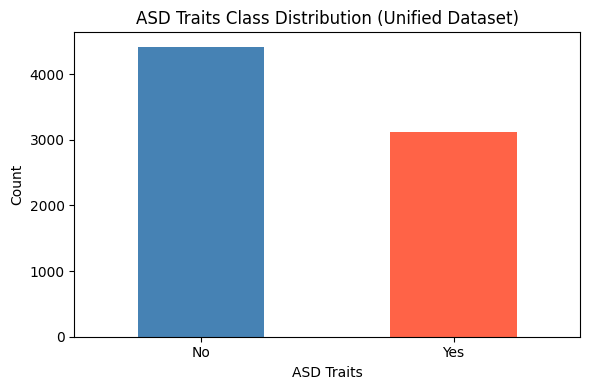

In [25]:
# Class balance check
print("ASD traits distribution:")
print(data['ASD_traits'].value_counts())

plt.figure(figsize=(6, 4))
data['ASD_traits'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('ASD Traits Class Distribution (Unified Dataset)')
plt.xlabel('ASD Traits')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Missing Value Check

In [26]:
missing = data[feature_cols].isnull().sum()
if missing.sum() == 0:
    print("No missing values found in the unified dataset.")
else:
    print("Missing values detected:")
    print(missing[missing > 0])

No missing values found in the unified dataset.


## 5. Preprocessing

Follows the same steps as `Q02.ipynb` to produce a dataset compatible with `QM1.ipynb`:
1. Drop columns not needed for modelling: `source`, `Age_in_Months`, `Jaundice`
2. Rename `A10` → `A10_Autism_Spectrum_Quotient`
3. One-hot encode categorical columns (`drop_first=True`)

In [35]:
# Drop columns not needed for modelling
data_proc = data.drop(columns=['source', 'Age_in_Months', 'Jaundice']).copy()
print(f"Dropped: source, Age_in_Months, Jaundice")

# Rename A10 to match QM1.ipynb convention
data_proc = data_proc.rename(columns={'A10': 'A10_Autism_Spectrum_Quotient'})

print("Columns after drop & rename:")
print(list(data_proc.columns))

Dropped: source, Age_in_Months, Jaundice
Columns after drop & rename:
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10_Autism_Spectrum_Quotient', 'Sex', 'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits']


In [36]:
# Age_in_Months and Jaundice already dropped — no scaling needed
print("No numeric columns require scaling after dropping Age_in_Months.")

No numeric columns require scaling after dropping Age_in_Months.


In [37]:
# One-hot encode all categorical columns (Jaundice already dropped)
categorical_cols = ['Sex', 'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits']
data_encoded = pd.get_dummies(data_proc, columns=categorical_cols, drop_first=True)

print("Columns after one-hot encoding:")
print(list(data_encoded.columns))
print(f"\nFinal shape: {data_encoded.shape}")

Columns after one-hot encoding:
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10_Autism_Spectrum_Quotient', 'Sex_M', 'Family_mem_with_ASD_Yes', 'Who_completed_the_test_Health Care Professional', 'Who_completed_the_test_Others', 'Who_completed_the_test_School and NGO', 'ASD_traits_Yes']

Final shape: (7530, 16)


In [38]:
# Verify data types
print("Data types:")
print(data_encoded.dtypes)

Data types:
A1                                                 int32
A2                                                 int32
A3                                                 int32
A4                                                 int32
A5                                                 int32
A6                                                 int32
A7                                                 int32
A8                                                 int32
A9                                                 int32
A10_Autism_Spectrum_Quotient                       int32
Sex_M                                               bool
Family_mem_with_ASD_Yes                             bool
Who_completed_the_test_Health Care Professional     bool
Who_completed_the_test_Others                       bool
Who_completed_the_test_School and NGO               bool
ASD_traits_Yes                                      bool
dtype: object


In [39]:
# Preview final dataset
data_encoded.head(5)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Sex_M,Family_mem_with_ASD_Yes,Who_completed_the_test_Health Care Professional,Who_completed_the_test_Others,Who_completed_the_test_School and NGO,ASD_traits_Yes
0,0,0,0,0,0,0,1,1,0,1,False,False,False,False,False,False
1,1,1,0,0,0,1,1,0,0,0,True,False,False,False,False,True
2,1,0,0,0,0,0,1,1,0,1,True,False,False,False,False,True
3,1,1,1,1,1,1,1,1,1,1,True,False,False,False,False,True
4,1,1,0,1,1,1,1,1,1,1,False,True,False,False,False,True


## 6. Summary Statistics

In [40]:
print("=== Final Unified Dataset Summary ===")
print(f"Total records : {len(data_encoded)}")
print(f"Total features: {data_encoded.shape[1] - 1}  (excluding target)")
print()
print("Class balance (ASD_traits_Yes):")
if 'ASD_traits_Yes' in data_encoded.columns:
    vc = data_encoded['ASD_traits_Yes'].value_counts()
    print(vc)
    print(f"ASD positive rate: {vc.get(True, 0) / len(data_encoded) * 100:.1f}%")
else:
    # drop_first may have produced a different column name
    asd_col = [c for c in data_encoded.columns if 'ASD' in c or 'asd' in c.lower()]
    print("ASD column(s) found:", asd_col)

print()
print("Records per original source (before dedup):")
for name, size in zip(source_names, source_sizes):
    print(f"  {name:<30}: {size}")

=== Final Unified Dataset Summary ===
Total records : 7530
Total features: 15  (excluding target)

Class balance (ASD_traits_Yes):
ASD_traits_Yes
False    4414
True     3116
Name: count, dtype: int64
ASD positive rate: 41.4%

Records per original source (before dedup):
  toddlers_csv                  : 1054
  children_csv                  : 2226
  child_arff                    : 288
  adolescent_arff               : 104
  screening_combined_csv        : 6075


## 7. Save the Unified Preprocessed Dataset

In [33]:
data_encoded.to_csv(OUTPUT_PATH, index=False)
print(f"Dataset saved to:\n  {OUTPUT_PATH}")
print(f"Final shape: {data_encoded.shape}")

Dataset saved to:
  C:\Users\Yasindu\Desktop\Stuff\Research\Datasets\PrePROCESSED DATA\pre_processed_data_combined.csv
Final shape: (7530, 18)
